<a href="https://colab.research.google.com/github/RithvikReddy0-0/ml_lab/blob/main/LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

project_path = '/content/drive/MyDrive/GenomeDetector'
natural_data_path = os.path.join(project_path, 'data', 'natural2')
engineered_data_path = os.path.join(project_path, 'data', 'engineered')

!pip install biopython

print("Environment is ready. Paths are set to your 'natural2' and 'engineered' folders.")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 44.5 MB/s eta 0:00:00
Environment is ready. Paths are set to your 'natural2' and 'engineered' folders.


In [ ]:
import numpy as np
from itertools import product
from Bio import SeqIO
import glob
import os
import gzip

def get_kmer_features(k):
    """Generates all possible k-mers for a given k."""
    letters = ['A', 'C', 'G', 'T']
    return sorted([''.join(p) for p in product(letters, repeat=k)])

def sequence_to_kmer_counts(sequence, k, kmer_features):
    """Converts a DNA sequence into a vector of k-mer counts."""
    kmer_counts = {kmer: 0 for kmer in kmer_features}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k].upper()
        if kmer in kmer_counts:
            kmer_counts[kmer] += 1
    return list(kmer_counts.values())

# --- Main Loading Logic ---
print("--- Loading and Processing Your Datasets ---")
K_VALUE = 4
kmer_features = get_kmer_features(K_VALUE)
X, y = [], []

# 1. Load Natural Data from 'natural2' (handles .fna and .fna.gz)
print("Loading 'Natural' genomes from the 'natural2' folder...")
# The '*' wildcard finds files ending in .fna or .fna.gz
search_pattern_natural = f"{natural_data_path}/*.fna*"
natural_files = glob.glob(search_pattern_natural)

for filepath in natural_files:
    # Open the file correctly, whether it's gzipped or not
    handle = gzip.open(filepath, "rt") if filepath.endswith(".gz") else open(filepath, "r")
    for record in SeqIO.parse(handle, "fasta"):
        if len(record.seq) > 1000:
            X.append(sequence_to_kmer_counts(str(record.seq), K_VALUE, kmer_features))
            y.append(0) # Label 0 for Natural
    handle.close()

# 2. Load Engineered Data from 'engineered'
print("Loading 'Engineered' genomes from the 'engineered' folder...")
search_pattern_engineered = f"{engineered_data_path}/*.fasta"
engineered_files = glob.glob(search_pattern_engineered)

for filepath in engineered_files:
    for record in SeqIO.parse(filepath, "fasta"):
        if 200 < len(record.seq) < 50000:
            X.append(sequence_to_kmer_counts(str(record.seq), K_VALUE, kmer_features))
            y.append(1) # Label 1 for Engineered

X = np.array(X)
y = np.array(y)

print("\n--- Data Processing Complete! ---")
print(f"Shape of our final feature matrix X: {X.shape}")
print(f"Shape of our final label vector y: {y.shape}")
print(f"Number of Natural samples (class 0): {np.sum(y == 0)}")
print(f"Number of Engineered samples (class 1): {np.sum(y == 1)}")

--- Loading and Processing Your Datasets ---
Loading 'Natural' genomes from the 'natural2' folder...
Loading 'Engineered' genomes from the 'engineered' folder...

--- Data Processing Complete! ---
Shape of our final feature matrix X: (9017, 256)
Shape of our final label vector y: (9017,)
Number of Natural samples (class 0): 8151
Number of Engineered samples (class 1): 866



--- A1 & A2: Linear Regression with One Feature ---
Train -> MSE: 0.0851, RMSE: 0.2917, MAPE: 384456421763131.0625, R2: 0.0008
Test  -> MSE: 0.0907, RMSE: 0.3011, MAPE: 380909819585479.8125, R2: 0.0005

--- A3: Linear Regression with All Features ---
Train -> MSE: 0.0420, RMSE: 0.2049, MAPE: 394658586117287.6250, R2: 0.5068
Test  -> MSE: 0.2822, RMSE: 0.5312, MAPE: 492929741943494.5000, R2: -2.1110

--- A4: K-Means Clustering with k=2 ---
Cluster Centers:
[[1.78089361e+02 1.20751391e+02 1.21309481e+02 1.43909637e+02
  1.38606722e+02 1.28583241e+02 1.43201202e+02 1.12138771e+02
  1.37499444e+02 1.89019141e+02 1.70104385e+02 1.11179279e+02
  1.20120743e+02 1.17204318e+02 1.18234253e+02 1.15197752e+02
  1.16483419e+02 1.11297685e+02 1.22508903e+02 1.09773759e+02
  1.89518362e+02 1.41045849e+02 2.18400067e+02 1.66990318e+02
  1.73911418e+02 2.55274204e+02 2.03123414e+02 1.37803138e+02
  6.01998665e+01 9.99362341e+01 1.14174828e+02 1.12120632e+02
  1.25613510e+02 1.02608613e+02 9.82424883e

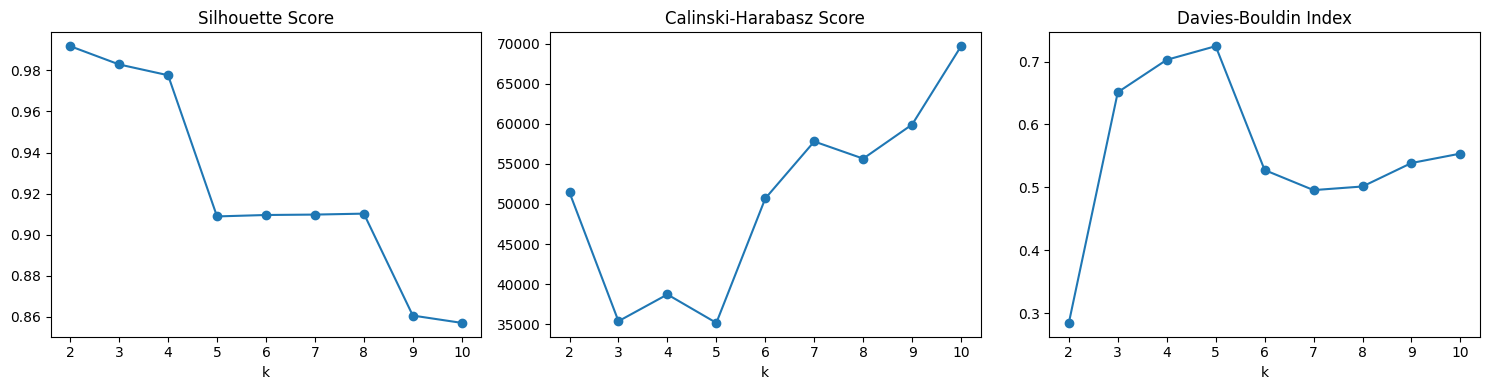


--- A7: Elbow Method ---


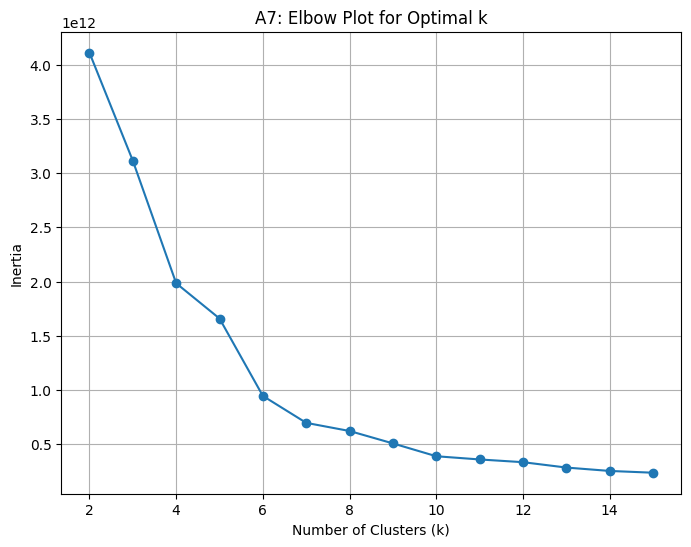

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def train_linear_regression_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mape, r2

def perform_kmeans(X, n_clusters):
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    model.fit(X)
    return model

def evaluate_clustering(X, labels):
    silhouette = silhouette_score(X, labels)
    ch_score = calinski_harabasz_score(X, labels)
    db_index = davies_bouldin_score(X, labels)
    return silhouette, ch_score, db_index

def elbow_plot(X, max_k=15):
    distortions = []
    for k in range(2, max_k + 1):
        model = KMeans(n_clusters=k, random_state=42, n_init="auto").fit(X)
        distortions.append(model.inertia_)
    plt.figure(figsize=(8, 6))
    plt.plot(range(2, max_k + 1), distortions, marker='o')
    plt.title("A7: Elbow Plot for Optimal k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

from sklearn.model_selection import train_test_split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X, y, test_size=0.3, random_state=42)

# A1 & A2: Regression with One Feature
print("\n--- A1 & A2: Linear Regression with One Feature ---")
X_single_train = X_reg_train[:, [0]]
X_single_test = X_reg_test[:, [0]]
reg_single = train_linear_regression_model(X_single_train, y_reg_train)
y_train_pred_single = reg_single.predict(X_single_train)
y_test_pred_single = reg_single.predict(X_single_test)
mse_tr, rmse_tr, mape_tr, r2_tr = evaluate_regression(y_reg_train, y_train_pred_single)
mse_te, rmse_te, mape_te, r2_te = evaluate_regression(y_reg_test, y_test_pred_single)

print(f"Train -> MSE: {mse_tr:.4f}, RMSE: {rmse_tr:.4f}, MAPE: {mape_tr:.4f}, R2: {r2_tr:.4f}")
print(f"Test  -> MSE: {mse_te:.4f}, RMSE: {rmse_te:.4f}, MAPE: {mape_te:.4f}, R2: {r2_te:.4f}")

# A3: Regression with All Features
print("\n--- A3: Linear Regression with All Features ---")
reg_all = train_linear_regression_model(X_reg_train, y_reg_train)
y_train_pred_all = reg_all.predict(X_reg_train)
y_test_pred_all = reg_all.predict(X_reg_test)
mse_tr_all, rmse_tr_all, mape_tr_all, r2_tr_all = evaluate_regression(y_reg_train, y_train_pred_all)
mse_te_all, rmse_te_all, mape_te_all, r2_te_all = evaluate_regression(y_reg_test, y_test_pred_all)

print(f"Train -> MSE: {mse_tr_all:.4f}, RMSE: {rmse_tr_all:.4f}, MAPE: {mape_tr_all:.4f}, R2: {r2_tr_all:.4f}")
print(f"Test  -> MSE: {mse_te_all:.4f}, RMSE: {rmse_te_all:.4f}, MAPE: {mape_te_all:.4f}, R2: {r2_te_all:.4f}")

# A4: KMeans Clustering with k=2
print("\n--- A4: K-Means Clustering with k=2 ---")
X_clustering = X.copy()
kmeans_2 = perform_kmeans(X_clustering, n_clusters=2)
print(f"Cluster Centers:\n{kmeans_2.cluster_centers_}")

# A5: Clustering Evaluation
print("\n--- A5: Clustering Evaluation (k=2) ---")
silhouette, ch_score, db_index = evaluate_clustering(X_clustering, kmeans_2.labels_)
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")

# A6: Clustering Scores for Multiple k
print("\n--- A6: Scores for k in range 2 to 10 ---")
k_values = list(range(2, 11))
silhouettes = []
chs = []
dbs = []

for k in k_values:
    model = perform_kmeans(X_clustering, n_clusters=k)
    s, c, d = evaluate_clustering(X_clustering, model.labels_)
    silhouettes.append(s)
    chs.append(c)
    dbs.append(d)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")

plt.subplot(1, 3, 2)
plt.plot(k_values, chs, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("k")

plt.subplot(1, 3, 3)
plt.plot(k_values, dbs, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("k")

plt.tight_layout()
plt.show()

# A7: Elbow Plot for Optimal k
print("\n--- A7: Elbow Method ---")
elbow_plot(X_clustering, max_k=15)


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def calculate_regression_metrics(y_true, y_pred):
    """Calculates and returns regression performance metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mape, r2


if 'X' not in locals() or X.shape[0] == 0:
    print("ERROR: Data variables 'X' and 'y' not found. Please run the data loading cell first.")
else:
    print("--- A1-A3: Linear Regression on k-mer Data ---")

    target_feature_index = 15
    y_reg = X[:, target_feature_index]

    X_reg = np.delete(X, target_feature_index, axis=1)

    print(f"Created a regression problem: using {X_reg.shape[1]} features to predict the count of one feature.")

    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

    lin_reg = LinearRegression()
    lin_reg.fit(X_reg_train, y_reg_train)

    y_pred_train = lin_reg.predict(X_reg_train)
    y_pred_test = lin_reg.predict(X_reg_test)

    mse_train, rmse_train, mape_train, r2_train = calculate_regression_metrics(y_reg_train, y_pred_train)
    mse_test, rmse_test, mape_test, r2_test = calculate_regression_metrics(y_reg_test, y_pred_test)

    print("\n--- Performance on TRAIN Set ---")
    print(f"MSE: {mse_train:.4f}, RMSE: {rmse_train:.4f}, MAPE: {mape_train:.4f}, R2 Score: {r2_train:.4f}")

    print("\n--- Performance on TEST Set ---")
    print(f"MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAPE: {mape_test:.4f}, R2 Score: {r2_test:.4f}")

    print("\n--- Analysis ---")
    print("The R2 Score measures how much of the variance in the target feature can be explained by the other features.")
    print("A score close to 1.0 means the features are highly correlated; a score close to 0 or negative means they are not.")

--- A1-A3: Linear Regression on k-mer Data ---
Created a regression problem: using 255 features to predict the count of one feature.

--- Performance on TRAIN Set ---
MSE: 0.0101, RMSE: 0.1003, MAPE: 5063003067125.0322, R2 Score: 1.0000

--- Performance on TEST Set ---
MSE: 0.0172, RMSE: 0.1313, MAPE: 6594143064541.5605, R2 Score: 1.0000

--- Analysis ---
The R2 Score measures how much of the variance in the target feature can be explained by the other features.
A score close to 1.0 means the features are highly correlated; a score close to 0 or negative means they are not.
